# Image Optimizer Notebook

Supports:
- JPEG, PNG, WebP, BMP, TIFF input
- Resize while preserving aspect ratio
- Target maximum dimensions
- Target maximum file size
- JPEG/WebP binary-search quality optimization
- PNG palette optimization


In [3]:
!pip install pillow

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   --------------------- ------------------ 3.9/7.2 MB 35.5 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 29.6 MB/s  0:00:00



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from PIL import Image
from pathlib import Path
import io, os

# ==========================
# USER CONFIGURATION
# ==========================

INPUT_IMAGE = r"C:\Users\VedantSonani\OneDrive - inkeysolutions.com\Desktop\Extension\images\test_2.png"
OUTPUT_FORMAT = "same"     # same, jpeg, png, webp

MAX_WIDTH = 1024
MAX_HEIGHT = 1024

TARGET_SIZE_KB = 30

RESIZE = True
COMPRESS = True
KEEP_ASPECT = True

JPEG_MIN_QUALITY = 20
JPEG_MAX_QUALITY = 95

WEBP_MIN_QUALITY = 20
WEBP_MAX_QUALITY = 95


In [19]:
def file_size_kb(path):
    return os.path.getsize(path)/1024

def image_info(path):
    img = Image.open(path)
    return {
        "format": img.format,
        "mode": img.mode,
        "width": img.width,
        "height": img.height,
        "size_kb": file_size_kb(path)
    }

def print_info(title, info):
    print("="*40)
    print(title)
    for k,v in info.items():
        print(f"{k:10}: {v}")


In [20]:
def resize_image(img):
    if not RESIZE:
        return img

    if KEEP_ASPECT:
        img.thumbnail((MAX_WIDTH, MAX_HEIGHT), Image.LANCZOS)
        return img

    return img.resize((MAX_WIDTH, MAX_HEIGHT), Image.LANCZOS)


In [21]:
def save_jpeg(img, output, target_kb):
    if img.mode in ("RGBA","LA","P"):
        img = img.convert("RGB")

    low = JPEG_MIN_QUALITY
    high = JPEG_MAX_QUALITY
    best = None

    while low <= high:
        q = (low + high)//2
        buf = io.BytesIO()

        img.save(buf,
                 format="JPEG",
                 quality=q,
                 optimize=True)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="JPEG",
                 quality=JPEG_MIN_QUALITY,
                 optimize=True)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [22]:
def save_webp(img, output, target_kb):
    low = WEBP_MIN_QUALITY
    high = WEBP_MAX_QUALITY
    best = None

    while low <= high:
        q = (low+high)//2

        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=q,
                 method=6)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=WEBP_MIN_QUALITY,
                 method=6)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [28]:
def save_png(img, output, target_kb):

    # palette_sizes = [256,128,64,32,16,8,4]
    palette_sizes = [256,128,64,32]

    best = None

    for colors in palette_sizes:

        test = img.convert(
            "P",
            palette=Image.ADAPTIVE,
            colors=colors
        )

        buf = io.BytesIO()

        test.save(buf,
                  format="PNG",
                  optimize=True,
                  compress_level=9)

        size = len(buf.getvalue())/1024

        best = buf.getvalue()

        if size <= target_kb:
            print(f"Achieved target size with {colors} colors.")
            break

    with open(output,"wb") as f:
        f.write(best)


In [24]:
def optimize_image(input_path):

    info = image_info(input_path)
    print_info("Original", info)

    img = Image.open(input_path)

    img = resize_image(img)

    fmt = OUTPUT_FORMAT.lower()

    if fmt == "same":
        fmt = info["format"].lower()

    output = Path(input_path).stem + "_optimized"

    if fmt in ("jpg","jpeg"):
        output += ".jpg"
        save_jpeg(img, output, TARGET_SIZE_KB)

    elif fmt == "png":
        output += ".png"
        save_png(img, output, TARGET_SIZE_KB)

    elif fmt == "webp":
        output += ".webp"
        save_webp(img, output, TARGET_SIZE_KB)

    else:
        raise ValueError(f"Unsupported output format: {fmt}")

    print()
    print_info("Optimized", image_info(output))

    reduction = (
        100
        * (1-file_size_kb(output)/info["size_kb"])
    )

    print(f"Reduction: {reduction:.2f}%")

    return output


Original
format    : PNG
mode      : RGB
width     : 1050
height    : 600
size_kb   : 103.3017578125

Optimized
format    : PNG
mode      : P
width     : 1024
height    : 585
size_kb   : 30.25390625
Reduction: 70.71%
Saved: test_2_optimized.png


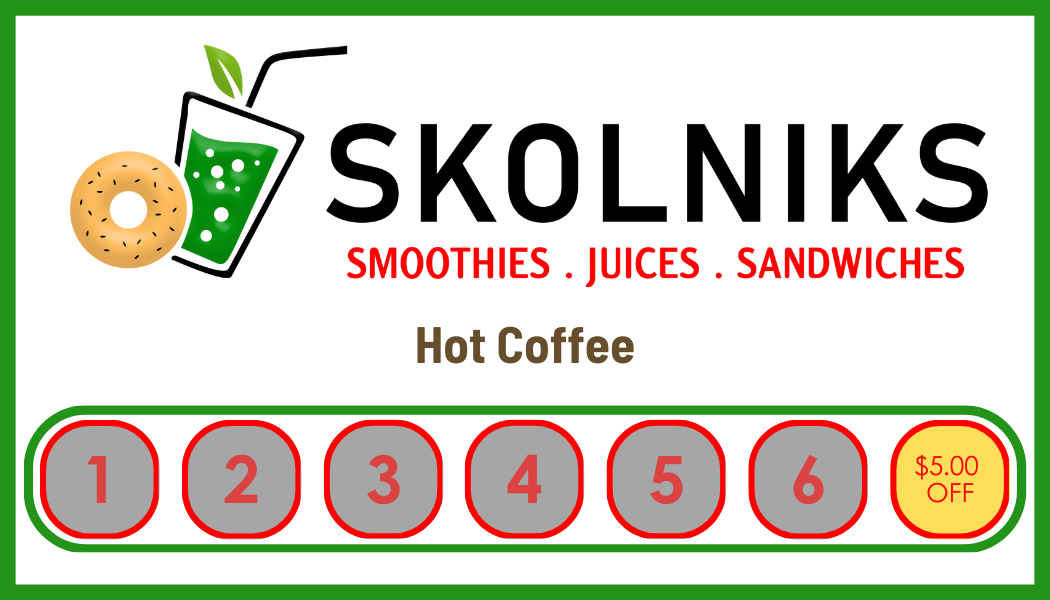

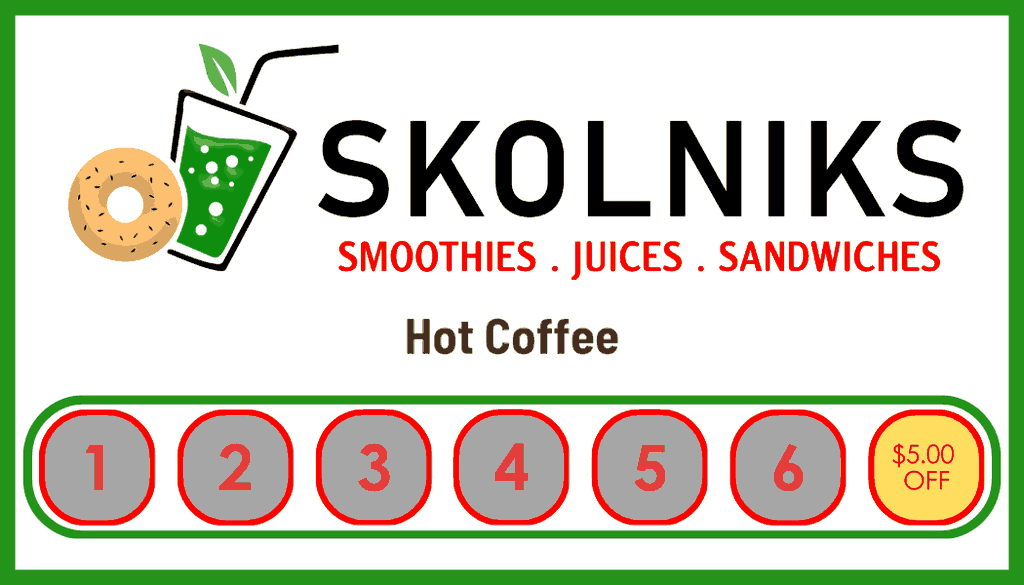

In [29]:
output = optimize_image(INPUT_IMAGE)
print("Saved:", output)

from IPython.display import display

display(Image.open(INPUT_IMAGE))
display(Image.open(output))
